In [11]:
import os
import json
import pickle
import argparse
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import soundfile as sf
import tgt
from transformers import (
    Wav2Vec2CTCTokenizer,
    Wav2Vec2FeatureExtractor,
    Wav2Vec2Processor,
    Wav2Vec2ForCTC,
)
import gc
gc.collect()
torch.cuda.empty_cache()
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
TARGET_SR= 16000
class GumbelQuantizerEMA(nn.Module):
    def __init__(self, input_dim: int, num_vars: int = 320,
                 temp: float = 2.0, decay: float = 0.99):
        super().__init__()
        self.num_vars = num_vars
        self.temp     = temp
        self.decay    = decay

        self.weight_proj = nn.Linear(input_dim, num_vars)

        self.register_buffer("codevectors", torch.randn(num_vars, input_dim))
        self.register_buffer("cluster_size", torch.ones(num_vars))
        self.register_buffer("ema_embed",   torch.randn(num_vars, input_dim))
        nn.init.uniform_(self.codevectors, -1.0, 1.0)

    def forward(self, X: torch.Tensor):
        B, T, D = X.shape
        logits   = self.weight_proj(X)

        if self.training:
            probs = F.gumbel_softmax(logits, tau=self.temp, hard=True)

            with torch.no_grad():
                flat_probs = probs.reshape(-1, self.num_vars)
                flat_X     = X.reshape(-1, D)
                counts     = flat_probs.sum(0)
                embed_sum  = flat_probs.T @ flat_X

                self.cluster_size = (self.decay * self.cluster_size
                                     + (1 - self.decay) * counts)
                self.ema_embed    = (self.decay * self.ema_embed
                                     + (1 - self.decay) * embed_sum)
                self.codevectors  = (self.ema_embed
                                     / self.cluster_size.unsqueeze(1).clamp(min=1e-5))
        else:
            indices = logits.argmax(dim=-1)
            probs   = F.one_hot(indices, self.num_vars).float()

        quantized = torch.matmul(probs, self.codevectors)
        return quantized, probs
# =========================
# Step 9: Model
# =========================

class Wav2Vec2ForCTC_FS_REC(nn.Module):
    def __init__(self, base_model, vocab_size, hidden_dim,
                 ctc_tokenizer, n_negatives=50, temperature=0.1):
        super().__init__()
        self.wav2vec2            = base_model.wav2vec2
        self.ctc_head            = base_model.lm_head
        self.ctc_tokenizer       = ctc_tokenizer
        self.n_negatives         = n_negatives
        self.temperature         = temperature
        self.align_temperature   = 5.0                              # ← must match training
        self.fx                  = nn.Linear(hidden_dim, hidden_dim, bias=False)  # ← no bias
        self.quantizer           = GumbelQuantizerEMA(input_dim=hidden_dim)
        self.reconstruction_head = nn.Linear(2 * hidden_dim, hidden_dim)

    def _ctc_decode_batch(self, logits):
        pred_ids  = logits.argmax(dim=-1)
        sequences = []
        for seq in pred_ids:
            unique_mask = torch.cat([
                torch.tensor([True], device=seq.device),
                seq[1:] != seq[:-1]
            ])
            collapsed = seq[unique_mask]
            collapsed = collapsed[collapsed != 0]
            if collapsed.numel() == 0:
                collapsed = torch.tensor([1], device=seq.device)
            sequences.append(collapsed)
        return torch.nn.utils.rnn.pad_sequence(
            sequences, batch_first=True, padding_value=0
        )

    def compute_phoneme_embeddings_from_ctc(self, X, logits, labels_clean):
        B, T, D   = X.shape
        ctc_probs = logits.softmax(dim=-1)
        Y_emb_list = []
        for b in range(B):
            phone_embs = []
            for p_id in labels_clean[b]:
                p_id = p_id.item()
                if p_id == 0:
                    phone_embs.append(torch.zeros(D, device=X.device))
                    continue
                weights = ctc_probs[b, :, p_id]
                weight_sum = weights.sum()
                if weight_sum < 1e-6:
                    weights = torch.ones_like(weights) / weights.shape[0]
                else:
                    weights = weights / weight_sum
                emb = (weights.unsqueeze(-1) * X[b]).sum(0)
                phone_embs.append(emb)
            Y_emb_list.append(torch.stack(phone_embs))
        return torch.stack(Y_emb_list)

    def compute_alignment(self, X, Y_emb):
        B, T, D = X.shape
        _, N, _ = Y_emb.shape
        X_proj  = self.fx(X)
        X_norm  = F.normalize(X_proj, dim=-1)
        Y_norm  = F.normalize(Y_emb,  dim=-1)
        D_mat   = self.align_temperature * torch.matmul(
            Y_norm, X_norm.transpose(1, 2)
        )
        n_idx = torch.arange(N, device=X.device).float() / max(N - 1, 1)
        t_idx = torch.arange(T, device=X.device).float() / max(T - 1, 1)
        prior = -10.0 * (n_idx.unsqueeze(1) - t_idx.unsqueeze(0)) ** 2
        D_mat = D_mat + prior.unsqueeze(0)
        return torch.softmax(D_mat, dim=1)

    def forward(self, input_values, attention_mask=None):
        outputs      = self.wav2vec2(input_values, attention_mask=attention_mask)
        X            = outputs.last_hidden_state
        logits       = self.ctc_head(X)
    
        with torch.no_grad():
            labels_clean = self._ctc_decode_batch(logits)
    
        Y_emb = self.compute_phoneme_embeddings_from_ctc(
            X.detach(), logits.detach(), labels_clean
        )
        A = self.compute_alignment(X, Y_emb)
    
        # Return object with .logits so evaluate_per.py works unchanged
        return {
            "logits":       logits,
            "alignment":    A,
            "labels_clean": labels_clean,
        }

In [14]:
!python charsiu-main/fix_ctc_ckpt.py \
      --in_ckpt  /vol/experiments3/imbenamor/TAPAS-FRAIS/alignment_models/results/w2vCTC/checkpoint-23430 \
      --out_ckpt /vol/experiments3/imbenamor/TAPAS-FRAIS/alignment_models/results/w2vCTC/checkpoint-23430_fixed \
      --skip_lm_head \
      --new_vocab_size 42

[fix] loaded 424 tensors from /vol/experiments3/imbenamor/TAPAS-FRAIS/alignment_models/results/w2vCTC/checkpoint-23430 (safetensors)
[fix] pos_conv_embed: remapped weight_g/weight_v -> parametrizations.*
[fix] --skip_lm_head set, leaving lm_head untouched
[fix] wrote state_dict to /vol/experiments3/imbenamor/TAPAS-FRAIS/alignment_models/results/w2vCTC/checkpoint-23430_fixed
[fix] config.json: vocab_size 42 -> 42
[fix] copied training_args.bin

[fix] done. Use --pretrained_model /vol/experiments3/imbenamor/TAPAS-FRAIS/alignment_models/results/w2vCTC/checkpoint-23430_fixed in train_ctc_alignment.py


In [2]:
!python charsiu-main/plot_chunk_dtw.py --checkpoint /vol/experiments3/imbenamor/TAPAS-FRAIS/alignment_models/results/charsiu_2losses_priorwithoutsilentframes/checkpoint-43000 \
                            --audio /vol/corpora/Rhapsodie/wav16k_corrected_withsilence/Rhap-D2001.wav \
                          --chunk_idx 7 \
                          --output /vol/experiments3/imbenamor/TAPAS-FRAIS/alignment_models/Rhap-D2001_chunk4.png


[plot] checkpoint = /vol/experiments3/imbenamor/TAPAS-FRAIS/alignment_models/results/charsiu_2losses_priorwithoutsilentframes/checkpoint-43000
[plot] device     = cuda
Using cache found in /home/imbenamor/.cache/torch/hub/snakers4_silero-vad_master
[plot] using chunk 7/48  pad=[62.89, 74.93]  true=[63.39, 74.43]  speech_regions=1  silence_regions=2
[plot] T=601 frames  N=103 collapsed phones
[plot] phones: 9 d y ʒ ø n f i j d a b ɔ ʁ e d y n f a m @ s y i t d y n ʒ ø n b u ʁ ʒ w a z d i z § d y n ʒ ø n b u ʁ ʒ w a z v w a l a v u l ə ʁ ə ɡ ʁ ɛ t e z o ʒ u ʁ d y i a n § p a d y t u ʒ ə v u d ʁ ɛ ʁ ə p ʁ @ d ʁ
[plot] speech frames: 601 -> 552 after mask
[plot] wrote /vol/experiments3/imbenamor/TAPAS-FRAIS/alignment_models/Rhap-D2001_chunk4.png


In [5]:
!python charsiu-main/local/evaluation_charsiu_v2_vad.py --checkpoint /vol/experiments3/imbenamor/TAPAS-FRAIS/alignment_models/results/charsiu_2losses_priorwithoutsilentframes/checkpoint-43000 



Device: cuda
Checkpoint: /vol/experiments3/imbenamor/TAPAS-FRAIS/alignment_models/results/charsiu_2losses_priorwithoutsilentframes/checkpoint-43000
Vocab: /vol/experiments3/imbenamor/TAPAS-FRAIS/alignment_models/vocab_w2vCTC-woSIL.json
Model loaded.
Found 54 wav files in /vol/corpora/Rhapsodie/wav16k_corrected_withsilence
Using cache found in /home/imbenamor/.cache/torch/hub/snakers4_silero-vad_master

[Rhap-D0002] dur=290.6s  vad_coverage=276.9s (95.3%)  chunks=23  ref_ivs=2734
    chunk 0/22  pad=[0.17,17.62]  own=[0.17,17.39]  sil_regions=2  ivs=175 kept=175
    chunk 1/22  pad=[17.17,24.75]  own=[17.39,24.40]  sil_regions=3  ivs=79 kept=79
    chunk 2/22  pad=[24.05,48.59]  own=[24.40,48.37]  sil_regions=2  ivs=219 kept=219
    chunk 3/22  pad=[48.14,57.94]  own=[48.37,58.02]  sil_regions=4  ivs=58 kept=58
    chunk 4/22  pad=[58.09,63.99]  own=[58.02,63.71]  sil_regions=2  ivs=42 kept=42
    chunk 5/22  pad=[63.44,86.07]  own=[63.71,85.78]  sil_regions=2  ivs=224 kept=224
    chun

In [12]:
sampa_to_api_single = {'a': 'a', 'e': 'e','i': 'i','o': 'o','u': 'u','y': 'y','2': 'ø','9': '9','@': 'ə','E': 'ɛ','O': 'ɔ','a~': '@', 'e~': '5', '9~': '1',    
    'o~': '§', 'b': 'b','d': 'd','f': 'f','g': 'ɡ',
    'k': 'k','l': 'l','m': 'm','n': 'n','n=':'n','p': 'p','t': 't','v': 'v','w': 'w','z': 'z','j': 'j','R': 'ʁ','N': 'ŋ','H': 'ɥ','J': 'ɲ','S': 'ʃ','Z': 'ʒ','Z=': 'ʒ',
    's': 's',
    'm=': 'm',
    '_': '_',
    'spn': 'spn',
    'unk': 'spn',
    "%":'spn',
    "?":"spn",
    "0":"spn"
}
with open("vocab_w2vCTC-woSIL.json") as f:
    vocab = json.load(f)
hyp_to_ref = {
    **sampa_to_api_single,
    '@': '@',    # override: vocab '@' is the nasal vowel, not schwa
    'ts': 's',    # ADD — model sometimes outputs affricate, collapse to /s/
    'tʃ': 'ʃ'
}
def normalise_hyp_token(tok: str) -> str:
    """Convert a raw tokenizer token to the REF label space."""
    return hyp_to_ref.get(tok, tok)   # passthrough if not in map
def map_ref_to_api_single(ph, mapping):
    if ph in mapping:
        return mapping[ph]
    if ph is not None and ph != "":
        return ph
    return None

In [13]:
import soundfile as sf

def get_ref_intervals(clean_ref, audio_path, eps=0.1):
    if not clean_ref:
        return []
    audio, sr = sf.read(audio_path)
    audio_duration = len(audio) / sr
    ref_first      = clean_ref[0]["start"]
    ref_last       = clean_ref[-1]["end"]
    end_overshoot  = ref_last - audio_duration
    ref_span       = ref_last - ref_first

    needs_correction = False
    reason = ""

    # Case 1: ref clearly extends past audio
    if end_overshoot > eps:
        needs_correction = True
        reason = "end_overshoot"
    # Case 2: ref starts well after 0 but its span fits within the audio
    elif ref_first > 0.3 and ref_span <= audio_duration + eps:
        needs_correction = True
        reason = "ref_first only"

    if needs_correction:
        offset = ref_first
        print(f"  Session offset corrected ({reason}): "
              f"ref_first={ref_first:.3f}s, ref_last={ref_last:.3f}s, "
              f"audio={audio_duration:.3f}s, end_overshoot={end_overshoot:+.3f}s, "
              f"offset={offset:.3f}s")
        return [
            {
                "phoneme": item["phoneme"],
                "start":   max(0.0, round(item["start"] - offset, 6)),
                "end":     max(0.0, round(item["end"]   - offset, 6)),
            }
            for item in clean_ref
        ]
    else:
        return list(clean_ref)
from librosa.sequence import dtw
from itertools import groupby
def read_textgrid(tg_path, tier_name="sampa"):
    """
    Returns list of {'phoneme': str, 'start': float, 'end': float}.
    Skips silence intervals (empty label, SIL, sil, sp).
    """
    tg        = tgt.io.read_textgrid(tg_path)
    tier      = tg.get_tier_by_name(tier_name)
    silence_labels = {"", "SIL", "sil", "spn", "SP", "<SIL>", "_",
                      "0", "fe~", "sjo~", "Ra~"}
    intervals = []
    for iv in tier.intervals:
        label = iv.text.strip()
        if not label or label in silence_labels:
            continue
        phoneme = map_ref_to_api_single(label, sampa_to_api_single)
        if phoneme is None or phoneme in silence_labels:
            continue
        intervals.append({
            "phoneme": phoneme,
            "start":   round(iv.start_time, 6),
            "end":     round(iv.end_time,   6),
        })
    return intervals



def plot_chunk_alignment(A_TN: np.ndarray,
                         per_frame_phone: np.ndarray,
                         phone_tokens,
                         tokenizer,
                         output_path: str,
                         frame_shift: float = 0.02,
                         title: str = "",
                         time_offset: float = 0.0):
    """Render one chunk's alignment energy + DTW path as a PNG.

    A_TN              : [T, N] attention energy (frames × phones), sliced to
                        the N CTC-collapsed phones for this chunk.
    per_frame_phone   : [T] int array, the DTW per-frame phone-index
                        assignment (output of _dtw_align_energy).
    phone_tokens      : iterable of length N, the CTC token IDs of the
                        collapsed phone sequence (used to label the Y axis).
    tokenizer         : Wav2Vec2CTCTokenizer for decoding token IDs to phone
                        symbols.
    output_path       : PNG path to save.
    frame_shift       : seconds per frame (default 0.02).
    title             : free-text title.
    time_offset       : add this many seconds to every X tick label, so the
                        plot can show absolute audio time instead of chunk-
                        local time. Set to chunk["pad_start"] when plotting
                        from inside the main loop.

    The figure shows a viridis heatmap of log_softmax(energy) (Y = phone
    index 0..N-1, X = time); the DTW path is overlaid in white. Where the
    path is flat the model holds on the same phone for several frames;
    where it climbs steeply the model is moving through phones quickly.
    A healthy alignment looks like a tight diagonal staircase.
    """
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    T, N = A_TN.shape
    if N == 0 or T == 0:
        return
    duration = T * frame_shift

    # log_softmax over phones — same normalisation training uses
    e = A_TN.astype(np.float64)
    e -= e.max(axis=1, keepdims=True)
    log_emit = e - np.log(np.exp(e).sum(axis=1, keepdims=True))   # [T, N]

    fig, ax = plt.subplots(figsize=(max(10, duration * 0.8),
                                    max(5, N * 0.15)))

    extent = [time_offset, time_offset + duration, -0.5, N - 0.5]
    ax.imshow(log_emit.T, aspect="auto", origin="lower",
              cmap="viridis", extent=extent, interpolation="nearest")

    # DTW path: phone index assigned to each frame. Silence frames (sentinel
    # value -1, set by the CTC-blank mask in extract_intervals_forced) are
    # replaced with NaN so matplotlib breaks the line there — visually the
    # white path simply disappears wherever the model emitted blank, which
    # is what you want to see.
    times = time_offset + (np.arange(T) + 0.5) * frame_shift
    path = np.where(per_frame_phone >= 0,
                    per_frame_phone.astype(float),
                    np.nan)
    ax.plot(times, path, color="white", linewidth=1.5, label="DTW path")
    ax.scatter(times, path, color="white", s=3, alpha=0.5)

    # Y-axis: subsample phone tokens if N is large.
    tick_step = max(1, N // 40)
    tick_idx  = list(range(0, N, tick_step))
    tick_labels = []
    for i in tick_idx:
        try:
            tok = tokenizer.convert_ids_to_tokens(int(phone_tokens[i]))
        except Exception:
            tok = str(int(phone_tokens[i]))
        tick_labels.append(f"{i}:{tok}")
    ax.set_yticks(tick_idx)
    ax.set_yticklabels(tick_labels, fontsize=6)

    ax.set_xlabel("time (s)" if time_offset > 0 else "time within chunk (s)")
    ax.set_ylabel("phone index : token")
    ax.set_xlim(time_offset, time_offset + duration)
    ax.set_ylim(-0.5, N - 0.5)
    ax.legend(loc="upper right", fontsize=8)
    ax.set_title(title or f"T={T} frames, N={N} phones, dur={duration:.2f}s",
                 fontsize=10)

    fig.savefig(output_path, dpi=140, bbox_inches="tight")
    plt.close(fig)


def _dtw_align_energy(A_TN: np.ndarray) -> np.ndarray:
    """Original-charsiu-style forced alignment via DTW on the attention energy.

    Mirrors src/utils.py:forced_align in upstream charsiu:
        D, wp = dtw(C=-softmax(out.logits)[:, target_phone_ids],
                    step_sizes_sigma=[[1, 1], [1, 0]])
    Step sizes [1, 1] (advance frame and phone) and [1, 0] (advance frame,
    stay on phone) — no skip, no backtracking, every frame consumed exactly
    once, no blank states. Each phone in the target sequence gets at least
    one frame.

    A_TN: [T, N] attention energy already sliced to the N collapsed phones.
    Returns: [T] int array, per-frame phone index in 0..N-1 as chosen by DTW.
    """
    T, N = A_TN.shape
    if N == 0:
        return np.zeros(T, dtype=np.int32)
    if N == 1:
        return np.zeros(T, dtype=np.int32)

    # softmax over phones → P(phone | frame); negate so DTW minimises.
    e = A_TN.astype(np.float64)
    e -= e.max(axis=1, keepdims=True)
    pe = np.exp(e)
    cost = pe / pe.sum(axis=1, keepdims=True)            # [T, N]

    D, wp = dtw(C=-cost,
                step_sizes_sigma=np.array([[1, 1], [1, 0]]))

    # librosa returns the path in reverse (end → start). With these step
    # sizes every frame appears at most once; take the max phone index per
    # frame as a safety guard (upstream does the same).
    per_frame = np.full(T, -1, dtype=np.int32)
    for fr, ph in wp:
        if 0 <= fr < T and per_frame[fr] < ph:
            per_frame[fr] = ph

    # Forward-fill any unvisited frames (shouldn't happen with these step
    # sizes, but be defensive).
    last = 0
    for t in range(T):
        if per_frame[t] < 0:
            per_frame[t] = last
        else:
            last = per_frame[t]
    return per_frame


def extract_intervals_forced(logits, A, tokenizer, duration_sec: float,
                              frame_shift: float = 0.02,
                              plot_path: str = None,
                              plot_title: str = "",
                              plot_time_offset: float = 0.0) -> list:
    """Build (start, end, phone) intervals for one chunk using upstream
    charsiu's strategy: DTW alignment on the (softmaxed) attention energy
    against the CTC-collapsed phone sequence, then run-length grouping of
    per-frame phone indices into intervals via seq2duration-style counting.

    Times here are *chunk-local* (frame_index × frame_shift). The caller is
    responsible for adding chunk.pad_start to turn them into absolute times.
    Each chunk is treated as an independent audio file — full pipeline run
    end-to-end on its frames, no cross-chunk coupling in the alignment.
    """
    blank_id = tokenizer.pad_token_id
    skip = {"[PAD]", "[UNK]", "spn", "", None}

    pred_ids = logits[0].argmax(dim=-1).tolist()
    collapsed = []
    prev = None
    for tok in pred_ids:
        if tok != prev:
            if tok != blank_id:
                collapsed.append(tok)
        prev = tok

    # Diagnostic.
    non_blank = sum(1 for t in pred_ids if t != blank_id)
    skipped_unk_spn = sum(
        1 for c in collapsed
        if normalise_hyp_token(tokenizer.convert_ids_to_tokens(c)) in skip
    )
    print(
        f"  [chunk] raw_frames={len(pred_ids)}  non_blank={non_blank}  "
        f"collapsed={len(collapsed)}  skipped_unk_spn={skipped_unk_spn}  "
        f"kept={len(collapsed) - skipped_unk_spn}"
    )

    if not collapsed:
        return []

    N = len(collapsed)
    T = logits.shape[1]

    # CTC-blank silence mask. Mirrors the `sil_mask` / `nonsil_idx` step in
    # src/Charsiu.py:143 — DTW should only see speech frames, otherwise the
    # forced start at (frame=0, phone=0) and the [[1,1],[1,0]] step sizes
    # make the first phone absorb any leading pad silence (= the "stuck on
    # phone 0 for X frames" pattern visible in the chunk plots). The CTC
    # head's argmax is our silence detector: frames whose argmax is [PAD]
    # are blank/silence.
    pred_arr  = np.asarray(pred_ids, dtype=np.int64)
    is_speech = pred_arr != blank_id
    speech_idx = np.flatnonzero(is_speech)

    A_TN = A[0].cpu().float().numpy().T           # [T, N]

    if speech_idx.size == 0:
        # CTC saw only blank in this chunk — nothing to align.
        return []

    # DTW runs on the non-silence frames only; result has length T_speech.
    A_TN_speech = A_TN[speech_idx]
    per_frame_phone_speech = _dtw_align_energy(A_TN_speech)

    # Lift back to full-length [T] frame assignment. Silence frames get the
    # sentinel -1 so the groupby below can recognise them as "_" runs and
    # skip them when emitting intervals (their timestamps still consume the
    # counter, so subsequent phone intervals get their correct absolute
    # start time = first speech frame, not chunk frame 0).
    per_frame_phone = np.full(T, -1, dtype=np.int32)
    per_frame_phone[speech_idx] = per_frame_phone_speech

    # Optional per-chunk plot of the energy heatmap + DTW path.
    if plot_path is not None:
        plot_chunk_alignment(
            A_TN=A_TN,
            per_frame_phone=per_frame_phone,
            phone_tokens=collapsed,
            tokenizer=tokenizer,
            output_path=plot_path,
            frame_shift=frame_shift,
            title=plot_title,
            time_offset=plot_time_offset,
        )

    # seq2duration: run-length encode the per-frame phone index sequence.
    # Silence runs (phone_idx == -1) advance the counter but produce no
    # interval — mirrors upstream's _merge_silence by simply omitting silence
    # from the hyp output (the user wants silence dropped on both sides).
    intervals = []
    counter = 0
    for phone_idx, group in groupby(per_frame_phone.tolist()):
        length = sum(1 for _ in group)
        if phone_idx == -1:
            counter += length
            continue
        raw_tok = tokenizer.convert_ids_to_tokens(int(collapsed[phone_idx]))
        phoneme_str = normalise_hyp_token(raw_tok)
        if phoneme_str not in skip:
            intervals.append({
                "phoneme": phoneme_str,
                "start":   round(counter * frame_shift, 6),
                "end":     round((counter + length) * frame_shift, 6),
            })
        counter += length

    return intervals


In [14]:
import numpy as np
from VAD_chunk import *
def intervals_to_frame_mask(intervals, T, frame_shift):
    """
    intervals: list of {"start": float, "end": float}
    returns: boolean mask of shape [T], True = keep frame
    """
    mask = np.zeros(T, dtype=bool)
    frame_centers = (np.arange(T) + 0.5) * frame_shift

    for iv in intervals:
        s = iv["start"]
        e = iv["end"]
        mask |= (frame_centers >= s) & (frame_centers < e)

    return mask
import numpy as np
from itertools import groupby

def extract_intervals_forced_vad(
    logits,
    A,
    tokenizer,
    duration_sec: float,
    chunk: dict = None,
    frame_shift: float = 0.02,
    plot_path: str = None,
    plot_title: str = "",
    plot_time_offset: float = 0.0,
) -> list:
    """
    Build (start, end, phoneme) intervals for one chunk.

    Uses VAD silence regions inside the chunk to mask out silent frames,
    then runs DTW on the remaining speech frames only.
    """
    skip = {"[PAD]", "[UNK]", "spn", "", None}

    # --- CTC argmax only to get the collapsed phone sequence ---
    pred_ids = logits[0].argmax(dim=-1).tolist()
    collapsed = []
    prev = None
    for tok in pred_ids:
        if tok != prev:
            if tok != tokenizer.pad_token_id:
                collapsed.append(tok)
        prev = tok

    if not collapsed:
        return []

    N = len(collapsed)
    T = logits.shape[1]

    # --- Build VAD-based speech mask inside the chunk ---
    # If no chunk / no silence info is provided, keep all frames.
    speech_mask = np.ones(T, dtype=bool)

    if chunk is not None:
        silence_regions = chunk.get("silence_regions", [])
        frame_centers = (np.arange(T) + 0.5) * frame_shift

        for sil in silence_regions:
            s = sil["start"] - chunk["pad_start"]  # convert absolute -> chunk-local
            e = sil["end"]   - chunk["pad_start"]
            speech_mask &= ~((frame_centers >= s) & (frame_centers < e))

    speech_idx = np.flatnonzero(speech_mask)

    if speech_idx.size == 0:
        return []

    # --- DTW on speech frames only ---
    A_TN = A[0].cpu().float().numpy().T          # [T, N]
    A_TN_speech = A_TN[speech_idx]
    per_frame_phone_speech = _dtw_align_energy(A_TN_speech)

    # --- Lift back to full-length frame labels ---
    per_frame_phone = np.full(T, -1, dtype=np.int32)
    per_frame_phone[speech_idx] = per_frame_phone_speech

    # --- Optional plot ---
    if plot_path is not None:
        plot_chunk_alignment(
            A_TN=A_TN,
            per_frame_phone=per_frame_phone,
            phone_tokens=collapsed,
            tokenizer=tokenizer,
            output_path=plot_path,
            frame_shift=frame_shift,
            title=plot_title,
            time_offset=plot_time_offset,
        )

    # --- Run-length grouping into intervals ---
    intervals = []
    counter = 0

    for phone_idx, group in groupby(per_frame_phone.tolist()):
        length = sum(1 for _ in group)

        if phone_idx == -1:
            counter += length
            continue

        raw_tok = tokenizer.convert_ids_to_tokens(int(collapsed[phone_idx]))
        phoneme_str = normalise_hyp_token(raw_tok)

        if phoneme_str not in skip:
            intervals.append({
                "phoneme": phoneme_str,
                "start": round(counter * frame_shift, 6),
                "end": round((counter + length) * frame_shift, 6),
            })

        counter += length

    return intervals

In [15]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def visualize_alignment_with_dtw(entry, fname, tokenizer,
                                 out_dir="results/alignment_plots",
                                 max_phones=80):
    """
    Plot alignment heatmap for each chunk + the FINAL DTW path used by
    extract_intervals_forced().
    """
    os.makedirs(out_dir, exist_ok=True)

    a_chunks = entry.get("A_chunks", [])
    logits_chunks = entry.get("logits_chunks", [])

    if not a_chunks:
        print(f"  No A matrix stored for {fname}")
        return
    if not logits_chunks:
        print(f"  No logits stored for {fname}")
        return

    blank_id = tokenizer.pad_token_id

    for chunk_idx, (A, logits) in enumerate(zip(a_chunks, logits_chunks)):
        # A is typically stored as [N, T]
        A_np = A.numpy() if torch.is_tensor(A) else np.asarray(A)
        if A_np.ndim != 2:
            print(f"  [SKIP] chunk {chunk_idx}: bad A shape {A_np.shape}")
            continue

        N, T = A_np.shape
        N_plot = min(N, max_phones)
        A_plot = A_np[:N_plot, :]

        # Final DTW path comes from the same logic as extract_intervals_forced
        pred_ids = logits[0].argmax(dim=-1).detach().cpu().numpy()
        is_speech = pred_ids != blank_id
        speech_idx = np.flatnonzero(is_speech)

        if speech_idx.size == 0:
            print(f"  [SKIP] chunk {chunk_idx}: no speech frames")
            continue

        # DTW works on speech frames only
        A_TN = A_np.T                      # [T, N]
        A_TN_speech = A_TN[speech_idx]     # [T_speech, N]
        per_frame_phone_speech = _dtw_align_energy(A_TN_speech)

        # Put it back to full chunk length, silence = NaN
        per_frame_phone = np.full(T, np.nan, dtype=np.float32)
        per_frame_phone[speech_idx] = per_frame_phone_speech

        fig = plt.figure(figsize=(min(T * 0.05, 24), 6))
        gs = gridspec.GridSpec(2, 1, height_ratios=[4, 1], hspace=0.08)

        # Top: heatmap + DTW path
        ax_heat = fig.add_subplot(gs[0])
        ax_heat.imshow(
            A_plot,
            aspect="auto",
            origin="upper",
            cmap="Blues",
            interpolation="nearest",
        )

        x = np.arange(T)[~np.isnan(per_frame_phone)]
        y = per_frame_phone[~np.isnan(per_frame_phone)]
        ax_heat.plot(x, y, color="red", lw=1.5, label="DTW path")

        ax_heat.set_ylabel("Phone")
        ax_heat.set_xticks([])
        ax_heat.set_title(
            f"{fname}  chunk {chunk_idx+1}/{len(a_chunks)}  (N={N}, T={T})",
            fontsize=9,
        )
        ax_heat.legend(fontsize=7, loc="upper left")

        # Bottom: DTW path as a step-like sequence
        ax_path = fig.add_subplot(gs[1], sharex=ax_heat)
        ax_path.plot(per_frame_phone, color="darkorange", lw=1.2, label="DTW per-frame phone")
        ax_path.set_xlabel("Frame")
        ax_path.set_ylabel("Ph idx")
        ax_path.set_ylim(-1, N)
        ax_path.legend(fontsize=7, loc="upper left")

        plt.tight_layout()
        save_path = os.path.join(out_dir, f"{fname}_chunk{chunk_idx+1:02d}.png")
        fig.savefig(save_path, dpi=120, bbox_inches="tight")
        plt.close(fig)
        print(f"  Saved: {save_path}")

In [16]:
from metrics import *
def prepare_alignment_store(results):
    """
    Convert the inference-loop `results` dict into the format expected by
    metrics() / metrics_rhap().

    Adds:
      - ref_seq:  list of ref phoneme labels (from ref_intervals)
      - hyp_seq:  list of hyp phoneme labels (from hyp_intervals)
      - style:    'M' (monologue) or 'D' (dialogue), inferred from filename
                  (Rhap-M*** vs Rhap-D***). Only needed for metrics_rhap.
    """
    alignment_store = {}
    for filename, data in results.items():
        ref_intervals = data["ref_intervals"]
        hyp_intervals = data["hyp_intervals"]

        # Infer style from filename — Rhap-specific naming
        parts  = filename.split("-")
        prefix = parts[1] if len(parts) > 1 else ""
        if   prefix.startswith("M"): style = "M"
        elif prefix.startswith("D"): style = "D"
        else:                         style = "unknown"

        alignment_store[filename] = {
            "ref_intervals": ref_intervals,
            "hyp_intervals": hyp_intervals,
            "ref_seq":       [iv["phoneme"] for iv in ref_intervals],
            "hyp_seq":       [iv["phoneme"] for iv in hyp_intervals],
            "style":         style,
        }
    return alignment_store

In [17]:
import pickle
from collections import defaultdict

import pickle

def pkl_to_etf_aligned(pkl_path, vocab,output_ref, output_hyp):
    import pickle

    with open(pkl_path, "rb") as f:
        data = pickle.load(f)

    # vocab global (from ref)
    
    vocab = list(vocab.keys())[2:]

    with open(output_ref, "w") as out_ref, open(output_hyp, "w") as out_hyp:

        for filename, content in data.items():

            ref_intervals = sorted(content["ref_intervals"], key=lambda x: x["start"])
            hyp_intervals = sorted(content["hyp_intervals"], key=lambda x: x["start"])

            for rseg in ref_intervals:
                start = rseg["start"]
                end = rseg["end"]
                duration = end - start
                ref_ph = rseg["phoneme"]

                if duration <= 0:
                    continue

                # find hyp phoneme overlapping this segment
                hyp_ph = None
                for hseg in hyp_intervals:
                    if not (hseg["end"] <= start or hseg["start"] >= end):
                        hyp_ph = hseg["phoneme"]
                        break

                for ph in vocab:
                    ref_dec = "t" if ph == ref_ph else "f"
                    hyp_dec = "t" if ph == hyp_ph else "f"

                    line_ref = f"{filename} 1 {start:.6f} {duration:.6f} sc - {ph} - {ref_dec}\n"
                    line_hyp = f"{filename} 1 {start:.6f} {duration:.6f} sc - {ph} - {hyp_dec}\n"

                    out_ref.write(line_ref)
                    out_hyp.write(line_hyp)

In [18]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

audio_dir = "/vol/corpora/Rhapsodie/wav16k_corrected_withsilence/"
textgrid_dir = "/vol/corpora/Rhapsodie/TextGrid.phones.sampa"
tier = "sampa"
device = "cuda"

# ── Processor ─────────────────────────────────────────────────────────
tokenizer = Wav2Vec2CTCTokenizer(
    vocab_file           = "vocab_w2vCTC-woSIL.json",
    unk_token            = "[UNK]",
    pad_token            = "[PAD]",
    word_delimiter_token = "",
)
feature_extractor = Wav2Vec2FeatureExtractor(
    feature_size         = 1,
    sampling_rate        = TARGET_SR,
    padding_value        = 0.0,
    do_normalize         = True,
    return_attention_mask = True,
)
print("Loading processor...")
tokenizer = Wav2Vec2CTCTokenizer(
    vocab_file= "vocab_w2vCTC-woSIL.json",
    unk_token="[UNK]",
    pad_token="[PAD]",
    word_delimiter_token="",
)
feature_extractor = Wav2Vec2FeatureExtractor(
    feature_size=1,
    sampling_rate=TARGET_SR,
    padding_value=0.0,
    do_normalize=True,
    return_attention_mask=True,
)
processor = Wav2Vec2Processor(
    feature_extractor=feature_extractor, tokenizer=tokenizer
)
ctc_checkpoint = "results/w2vCTC/checkpoint-23430"
audio_files = sorted(
    glob.glob(os.path.join(audio_dir, "**", "*.wav"), recursive=True)
)
with open("vocab_w2vCTC-woSIL.json") as f:
    vocab = json.load(f)
# ── Model ─────────────────────────────────────────────────────────────
print(f"Loading CTC architecture from {ctc_checkpoint}...")
base_model = Wav2Vec2ForCTC.from_pretrained(
    ctc_checkpoint,
    ctc_loss_reduction = "mean",
    ctc_zero_infinity  = True,
    pad_token_id       = tokenizer.pad_token_id,
    vocab_size         = len(tokenizer),
)
model = Wav2Vec2ForCTC_FS_REC(
    base_model,
    vocab_size = len(processor.tokenizer),
    hidden_dim = base_model.config.hidden_size,
    ctc_tokenizer = processor.tokenizer,
)

model.wav2vec2.feature_extractor._freeze_parameters()

Loading processor...
Loading CTC architecture from results/w2vCTC/checkpoint-23430...


Some weights of the model checkpoint at results/w2vCTC/checkpoint-23430 were not used when initializing Wav2Vec2ForCTC: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at results/w2vCTC/checkpoint-23430 and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN thi

In [19]:
from itertools import groupby
import numpy as np

from itertools import groupby

def extract_intervals_ctc(
    logits,
    tokenizer,
    frame_shift=0.02,
):
    """
    Pure CTC frame-run alignment.
    Returns chunk-local phoneme intervals.
    """

    blank_id = tokenizer.pad_token_id
    skip = {"[PAD]", "[UNK]", "spn", "", None}

    pred_ids = logits[0].argmax(dim=-1).tolist()

    intervals = []
    counter = 0

    for tok, group in groupby(pred_ids):
        length = sum(1 for _ in group)

        # skip blanks but keep time advancing
        if tok == blank_id:
            counter += length
            continue

        phoneme = normalise_hyp_token(
            tokenizer.convert_ids_to_tokens(tok)
        )

        if phoneme not in skip:
            intervals.append({
                "phoneme": phoneme,
                "start": round(counter * frame_shift, 6),
                "end": round((counter + length) * frame_shift, 6),
            })

        counter += length

    return intervals

In [20]:
import math
import torch

# Assumed already importable in your project:
#   from rVADfast import rVADfast
#   from your_utils import vad_to_speech_ts


# ─────────────────────────────────────────────────────────────────────────
# Helpers for splitting overlong VAD segments on internal pauses
# ─────────────────────────────────────────────────────────────────────────

def _find_pauses(audio, sampling_rate, min_pause=0.1, energy_percentile=15):
    """
    Find quiet regions inside `audio` (1D tensor).
    A 'pause' is a run of low-energy frames lasting at least `min_pause`
    seconds. Returns list of {start, end, mid, duration} in seconds,
    local to `audio`.
    """
    frame_len = int(0.02 * sampling_rate)        # 20 ms frames
    n_frames = audio.numel() // frame_len
    if n_frames == 0:
        return []

    frames = audio[: n_frames * frame_len].reshape(n_frames, frame_len)
    energy = frames.pow(2).mean(dim=1).sqrt()

    # Adaptive threshold: bottom Nth percentile of this segment's own energy.
    # Robust to overall loudness; assumes some frames are quieter than others.
    threshold = torch.quantile(energy, energy_percentile / 100.0)
    is_quiet = (energy < threshold).tolist()

    pauses = []
    min_pause_frames = max(1, int(min_pause * sampling_rate / frame_len))

    i = 0
    while i < len(is_quiet):
        if not is_quiet[i]:
            i += 1
            continue
        j = i
        while j < len(is_quiet) and is_quiet[j]:
            j += 1
        if j - i >= min_pause_frames:
            start_t = i * frame_len / sampling_rate
            end_t = j * frame_len / sampling_rate
            pauses.append({
                "start": start_t,
                "end": end_t,
                "mid": 0.5 * (start_t + end_t),
                "duration": end_t - start_t,
            })
        i = j

    return pauses


def _split_long_segment(
    seg,
    wav,
    sampling_rate,
    max_chunk_duration,
    min_chunk_duration,
    min_pause=0.1,
    energy_percentile=15,
):
    """
    Split a VAD segment longer than max_chunk_duration on its quietest
    internal pauses. Returns a list of {start, end} pieces.

    Decision tiers (in order):
      1) Pause inside [cur+min, cur+max] -> pick LONGEST (natural cut)
      2) Any pause in (cur, cur+max]     -> pick LATEST  (max piece size)
      3) No pause within max range       -> earliest future pause
                                            (piece may exceed max;
                                             silence-only wins over cap)
    """
    duration = seg["end"] - seg["start"]
    if duration <= max_chunk_duration:
        return [seg]

    # Pull the audio for this segment, find local pauses, lift to absolute time
    s_idx = int(seg["start"] * sampling_rate)
    e_idx = int(seg["end"] * sampling_rate)
    local_pauses = _find_pauses(
        wav[s_idx:e_idx], sampling_rate, min_pause, energy_percentile,
    )
    pauses = [{
        "start":    seg["start"] + p["start"],
        "end":      seg["start"] + p["end"],
        "mid":      seg["start"] + p["mid"],
        "duration": p["duration"],
    } for p in local_pauses]

    split_points = [seg["start"]]
    cur = seg["start"]

    while seg["end"] - cur > max_chunk_duration:
        # 1) Ideal: pause inside [cur+min, cur+max]
        ideal = [p for p in pauses
                 if cur + min_chunk_duration <= p["mid"] <= cur + max_chunk_duration]
        if ideal:
            best = max(ideal, key=lambda p: (p["duration"], p["mid"]))

        else:
            # 2) Any pause within max (rescue pass will fix sub-min pieces)
            upto_max = [p for p in pauses
                        if cur < p["mid"] <= cur + max_chunk_duration]
            if upto_max:
                best = max(upto_max, key=lambda p: p["mid"])

            else:
                # 3) No pause inside max — earliest future pause anyway
                future = [p for p in pauses if p["mid"] > cur]
                if not future:
                    break  # no silence at all, leave remainder as one piece
                best = min(future, key=lambda p: p["mid"])

        split_points.append(best["mid"])
        cur = best["mid"]

    split_points.append(seg["end"])
    split_points = sorted(set(split_points))

    return [{"start": split_points[i], "end": split_points[i + 1]}
            for i in range(len(split_points) - 1)]


# ─────────────────────────────────────────────────────────────────────────
# Main entry point
# ─────────────────────────────────────────────────────────────────────────

def vad_chunk_with_timestamps_v3(
    wav,
    sampling_rate=16000,
    max_chunk_duration=10.0,
    max_pause_duration=1.5,
    overlap=0.5,
    min_chunk_duration=2.0,
    split_min_pause=0.1,
    split_energy_percentile=15,
):
    """
    wav: torch.Tensor (1D, 16kHz)

    returns: list of dicts with:
        start/end         -> true speech span of the chunk
        pad_start/pad_end -> padded boundaries used for audio extraction
        speech_regions    -> list of speech intervals inside the chunk
        silence_regions   -> list of silence gaps inside the chunk

    Final chunks are kept within [min_chunk_duration, max_chunk_duration]
    whenever possible. Only unfixable case: the whole audio yields a
    single chunk shorter than min_chunk_duration (no neighbour to merge).

    Long VAD segments (>max_chunk_duration) are split on internal pauses
    detected via short-time energy. Controlled by:
        split_min_pause          - min silence duration to count as a pause
        split_energy_percentile  - per-segment energy threshold (percentile)
    """
    vad = rVADfast()
    vad_labels, vad_timestamps = vad(wav, sampling_rate)
    speech_ts = vad_to_speech_ts(vad_labels, vad_timestamps, sampling_rate)

    # Convert VAD timestamps from samples to seconds
    split_ts = []
    for seg in speech_ts:
        seg_start = seg["start"] / sampling_rate
        seg_end = seg["end"] / sampling_rate
        split_ts.append({"start": seg_start, "end": seg_end})

    # ── Split any VAD segment longer than max_chunk_duration ─────────────
    # rVADfast can produce very long continuous segments (100s+ of speech
    # with no detected silence). Cut them on their internal pauses so the
    # merging loop below can treat them like normal-sized segments.
    split_ts = [
        p
        for seg in split_ts
        for p in _split_long_segment(
            seg, wav, sampling_rate,
            max_chunk_duration, min_chunk_duration,
            min_pause=split_min_pause,
            energy_percentile=split_energy_percentile,
        )
    ]

    # ── Merge split_ts segments, enforcing min/max chunk duration ────────
    # A chunk keeps growing while EITHER:
    #   • it is still below min_chunk_duration   (force-grow), OR
    #   • the pause to the next segment is short (normal merging)
    # …provided the result still fits under max_chunk_duration.
    chunks = []
    chunk_start = None
    chunk_end = None
    chunk_speech_regions = []

    for seg in split_ts:
        seg_start = seg["start"]
        seg_end = seg["end"]

        if chunk_start is None:
            chunk_start = seg_start
            chunk_end = seg_end
            chunk_speech_regions = [{"start": seg_start, "end": seg_end}]
            continue

        current_duration = chunk_end - chunk_start
        pause = seg_start - chunk_end
        proposed_duration = seg_end - chunk_start

        below_min = current_duration < min_chunk_duration
        short_pause = pause <= max_pause_duration
        fits_max = proposed_duration <= max_chunk_duration

        if fits_max and (below_min or short_pause):
            chunk_speech_regions.append({"start": seg_start, "end": seg_end})
            chunk_end = seg_end
        else:
            chunks.append({
                "start": chunk_start,
                "end": chunk_end,
                "speech_regions": chunk_speech_regions,
            })
            chunk_start = seg_start
            chunk_end = seg_end
            chunk_speech_regions = [{"start": seg_start, "end": seg_end}]

    if chunk_start is not None:
        chunks.append({
            "start": chunk_start,
            "end": chunk_end,
            "speech_regions": chunk_speech_regions,
        })

    # ── Post-process: rescue any chunk still under min_chunk_duration ────
    # Only happens when the main loop had to close the chunk because
    # adding the next segment would have exceeded max. Merge into the
    # smaller neighbour; min wins over max in this rare conflict.
    def _merge(target, source):
        target["end"] = source["end"]
        target["speech_regions"].extend(source["speech_regions"])

    i = 0
    while i < len(chunks):
        dur = chunks[i]["end"] - chunks[i]["start"]
        if dur >= min_chunk_duration:
            i += 1
            continue

        has_prev = i > 0
        has_next = i + 1 < len(chunks)

        if not has_prev and not has_next:
            # Lone chunk shorter than min — nothing we can do
            break

        prev_dur = (chunks[i - 1]["end"] - chunks[i - 1]["start"]) if has_prev else float("inf")
        next_dur = (chunks[i + 1]["end"] - chunks[i + 1]["start"]) if has_next else float("inf")

        # Prefer the smaller neighbour to keep durations balanced
        if has_prev and (not has_next or prev_dur <= next_dur):
            _merge(chunks[i - 1], chunks[i])
            chunks.pop(i)
            i = max(0, i - 1)   # re-check merged chunk
        else:
            _merge(chunks[i], chunks[i + 1])
            chunks.pop(i + 1)
            # keep i — re-check merged chunk

    # ── Add silence regions + padding ────────────────────────────────────
    audio_duration = len(wav) / sampling_rate
    for chunk in chunks:
        speech_regions = chunk["speech_regions"]

        silence_regions = []
        for i in range(len(speech_regions) - 1):
            s1 = speech_regions[i]["end"]
            s2 = speech_regions[i + 1]["start"]
            if s2 > s1:
                silence_regions.append({"start": s1, "end": s2})

        chunk["silence_regions"] = silence_regions
        chunk["pad_start"] = max(0.0, chunk["start"] - overlap)
        chunk["pad_end"] = min(audio_duration, chunk["end"] + overlap)

    return chunks

In [21]:
#from VAD_chunk import vad_chunk_with_timestamps_v3

audio_files = sorted(
    glob.glob(os.path.join(audio_dir, "**", "*.wav"), recursive=True)
)
checkpoint_path = "results/w2vCTC_joint_nofxfy/checkpoint-781"


bin_path = os.path.join(checkpoint_path, "pytorch_model.bin")
sft_path = os.path.join(checkpoint_path, "model.safetensors")
if os.path.exists(bin_path):
    state_dict = torch.load(bin_path, map_location="cpu")
elif os.path.exists(sft_path):
    from safetensors.torch import load_file
    state_dict = load_file(sft_path)
else:
    raise FileNotFoundError(
        f"No model weights found in {checkpoint_path}\n"
        f"Expected pytorch_model.bin or model.safetensors"
    )

missing, unexpected = model.load_state_dict(state_dict, strict=False)

model.eval()
model.to(device)
print("Model ready.")

Model ready.


In [22]:
results_dtw = {}
results_ctc = {}
n_done = 0
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
for audio_path in os.listdir(audio_dir):
    audio_path = audio_dir + audio_path
    filename = os.path.splitext(os.path.basename(audio_path))[0]

    if filename == "Rhap-D2004":
        continue

    tg_path = os.path.join(textgrid_dir, filename + "-Pro.TextGrid")
    if not os.path.exists(tg_path):
        print(f"  [SKIP] No TextGrid for {filename}")
        continue

    clean_ref = read_textgrid(tg_path, tier)
    ref_intervals = get_ref_intervals(clean_ref, audio_path)

    audio, sr = sf.read(audio_path)
    if sr != TARGET_SR:
        import librosa
        audio = librosa.resample(audio, orig_sr=sr, target_sr=TARGET_SR)
    if audio.ndim > 1:
        audio = audio.mean(axis=1)

    wav = torch.from_numpy(audio.astype(np.float32))
    chunks = vad_chunk_with_timestamps_v3(wav, max_pause_duration=1.5)

    audio_duration = len(audio) / TARGET_SR
    covered = sum(c["end"] - c["start"] for c in chunks) if chunks else 0
    print(f"  VAD coverage: {covered:.1f}s / {audio_duration:.1f}s "
          f"({100*covered/audio_duration:.1f}%)")

    spn_count = sum(1 for iv in ref_intervals if iv["phoneme"] == "_")
    print(f"  Ref spn count: {spn_count} / {len(ref_intervals)}")

    if not chunks:
        duration = len(audio) / TARGET_SR
        chunks = [{
            "start": 0.0,
            "end": duration,
            "pad_start": 0.0,
            "pad_end": duration,
            "speech_regions": [{"start": 0.0, "end": duration}],
            "silence_regions": [],
        }]

    dtw_intervals_all = []
    ctc_intervals_all = []
    a_matrices = []
    all_logits = []

    for chunk_idx, chunk in enumerate(chunks):
        start_sample = int(chunk["pad_start"] * TARGET_SR)
        end_sample = int(chunk["pad_end"] * TARGET_SR)
        chunk_audio = audio[start_sample:end_sample]
        print(len(chunk_audio)/16000)
        if len(chunk_audio) < 400:
            continue

        inputs = feature_extractor(
            chunk_audio,
            sampling_rate=TARGET_SR,
            return_tensors="pt",
            return_attention_mask=True,
        )

        with torch.no_grad():
            outputs = model(
                inputs.input_values.to(device),
                attention_mask=inputs.attention_mask.to(device),
            )
            logits = outputs["logits"]      # [B, T, V]
            A = outputs["alignment"]        # [B, P, T]

        dur = len(chunk_audio) / TARGET_SR

        ctc_ivs = extract_intervals_ctc(logits, tokenizer)
        dtw_ivs = extract_intervals_forced_vad(
            logits, A, tokenizer, dur,
            chunk=chunk,
            plot_path=None,
            plot_title="alignment-matrix",
        )

        true_start = chunk["start"]
        true_end = chunk["end"]

        print(
            f"  chunk[{chunk_idx}]: "
            f"pad=[{chunk['pad_start']:.2f}, {chunk['pad_end']:.2f}]  "
            f"true=[{true_start:.2f}, {true_end:.2f}]  "
            f"n_ctc={len(ctc_ivs)}  n_dtw={len(dtw_ivs)}"
        )

        kept_ctc = 0
        for iv in ctc_ivs:
            abs_start = round(iv["start"] + chunk["pad_start"], 6)
            abs_end = round(iv["end"] + chunk["pad_start"], 6)
            centre = (abs_start + abs_end) / 2.0
            if not (true_start - 0.01 <= centre <= true_end + 0.01):
                continue
            ctc_intervals_all.append({
                "phoneme": normalise_hyp_token(iv["phoneme"]),
                "start": abs_start,
                "end": abs_end,
            })
            kept_ctc += 1
        print(f"    kept CTC (true-window centre filter): {kept_ctc}")

        kept_dtw = 0
        for iv in dtw_ivs:
            abs_start = round(iv["start"] + chunk["pad_start"], 6)
            abs_end = round(iv["end"] + chunk["pad_start"], 6)
            centre = (abs_start + abs_end) / 2.0
            if not (true_start - 0.01 <= centre <= true_end + 0.01):
                continue
            dtw_intervals_all.append({
                "phoneme": normalise_hyp_token(iv["phoneme"]),
                "start": abs_start,
                "end": abs_end,
            })
            kept_dtw += 1
        print(f"    kept DTW (true-window centre filter): {kept_dtw}")

        a_matrices.append(A[0].cpu())
        all_logits.append(logits.cpu())

    ctc_intervals_all.sort(key=lambda iv: iv["start"])
    dtw_intervals_all.sort(key=lambda iv: iv["start"])

    total_ctc_phones = sum(
        len([t for t in logits[0].argmax(-1).tolist()
             if t != tokenizer.pad_token_id])
        for logits in all_logits
    )
    print(f"  Raw CTC non-blank frames: {total_ctc_phones}, "
          f"ctc intervals: {len(ctc_intervals_all)}, "
          f"dtw intervals: {len(dtw_intervals_all)}, "
          f"ref: {len(ref_intervals)}")

    results_dtw[filename] = {
        "file": os.path.basename(audio_path),
        "ref_intervals": ref_intervals,
        "hyp_intervals": dtw_intervals_all,
        "A_chunks": a_matrices,
        "logits_chunks": all_logits,
    }

    results_ctc[filename] = {
        "file": os.path.basename(audio_path),
        "ref_intervals": ref_intervals,
        "hyp_intervals": ctc_intervals_all,
        "logits_chunks": all_logits,
    }

    n_done += 1
    print(f"[{n_done}] Done: {filename}  "
          f"({len(dtw_intervals_all)} dtw intervals, "
          f"{len(ctc_intervals_all)} ctc intervals, "
          f"{len(ref_intervals)} ref intervals)")



  VAD coverage: 16.8s / 22.3s (75.2%)
  Ref spn count: 0 / 166
8.88
  chunk[0]: pad=[0.00, 8.88]  true=[0.01, 8.38]  n_ctc=75  n_dtw=76
    kept CTC (true-window centre filter): 75
    kept DTW (true-window centre filter): 75
9.38
  chunk[1]: pad=[8.24, 17.62]  true=[8.74, 17.12]  n_ctc=89  n_dtw=91
    kept CTC (true-window centre filter): 89
    kept DTW (true-window centre filter): 89
  Raw CTC non-blank frames: 266, ctc intervals: 164, dtw intervals: 164, ref: 166
[1] Done: Rhap-M0012  (164 dtw intervals, 164 ctc intervals, 166 ref intervals)
  VAD coverage: 25.8s / 26.2s (98.4%)
  Ref spn count: 0 / 243
8.56
  chunk[0]: pad=[0.00, 8.56]  true=[0.01, 8.06]  n_ctc=73  n_dtw=75
    kept CTC (true-window centre filter): 70
    kept DTW (true-window centre filter): 72
9.950125
  chunk[1]: pad=[7.61, 17.56]  true=[8.11, 17.06]  n_ctc=90  n_dtw=92
    kept CTC (true-window centre filter): 83
    kept DTW (true-window centre filter): 85
9.3955
  chunk[2]: pad=[16.77, 26.17]  true=[17.27, 

In [23]:
alignment_store = prepare_alignment_store(results_dtw)

metrics(alignment_store, f"results/metrics_per_file_chunkingv2.csv")


In [16]:
with open("results/w2vctc_joint_nofxfy_chunkingv2/alignment_dict_dtw.pkl", "wb") as f:
    pickle.dump(alignment_store, f)

In [17]:
pkl_to_etf_aligned(f"results/w2vctc_joint_nofxfy_chunkingv2/alignment_dict_dtw.pkl",vocab, f"results/w2vctc_joint_nofxfy_chunkingv2/ref.etf",f"results/w2vctc_joint_nofxfy_chunkingv2/hyp.etf")

In [46]:
import pickle
with open('results/rhap_ctc_charsiu.pkl', 'rb') as fp:
    alignment_store = pickle.load(fp)

In [47]:
alignment_store['Rhap-M0012'].keys()

dict_keys(['file', 'ref_intervals', 'hyp_intervals', 'A_chunks', 'logits_chunks'])

In [48]:
metrics(alignment_store, f"results/metrics_charsiu_2losses.csv")

KeyError: 'ref_seq'

/tmp/ipykernel_3646048/4191958114.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved: results/w2vCTC_joint_v2_32K/Rhap-M0012-align/Rhap-M0012_chunk01.png
  Saved: results/w2vCTC_joint_v2_32K/Rhap-M0012-align/Rhap-M0012_chunk02.png
  Saved: results/w2vCTC_joint_v2_32K/Rhap-M0012-align/Rhap-M0012_chunk03.png
  Saved: results/w2vCTC_joint_v2_32K/Rhap-M0015-align/Rhap-M0015_chunk01.png
  [SKIP] chunk 0: no speech frames
  Saved: results/w2vCTC_joint_v2_32K/Rhap-M0022-align/Rhap-M0022_chunk01.png
  [SKIP] chunk 0: no speech frames
  Saved: results/w2vCTC_joint_v2_32K/Rhap-D0009-align/Rhap-D0009_chunk02.png
  Saved: results/w2vCTC_joint_v2_32K/Rhap-D0009-align/Rhap-D0009_chunk03.png
  Saved: results/w2vCTC_joint_v2_32K/Rhap-D0009-align/Rhap-D0009_chunk04.png
  Saved: results/w2vCTC_joint_v2_32K/Rhap-D0009-align/Rhap-D0009_chunk05.png
  Saved: results/w2vCTC_joint_v2_32K/Rhap-D0009-align/Rhap-D0009_chunk06.png
  Saved: results/w2vCTC_joint_v2_32K/Rhap-D0009-align/Rhap-D0009_chunk07.png
  Saved: results/w2vCTC_joint_v2_32K/Rhap-D0009-align/Rhap-D0009_chunk08.png
  Save

KeyboardInterrupt: 

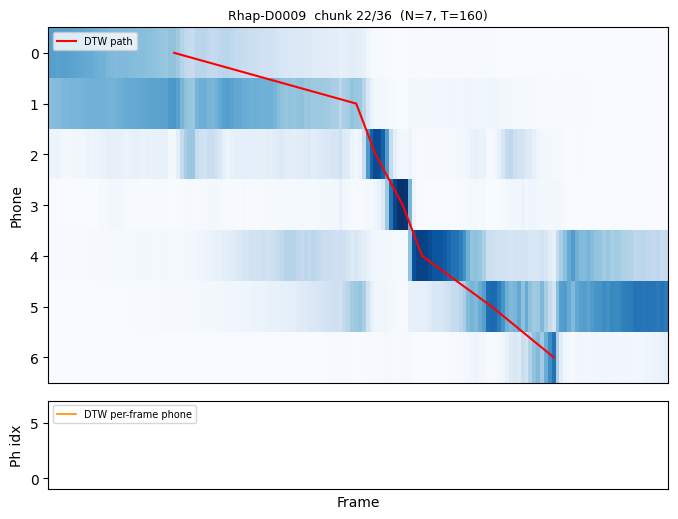

In [20]:
for fname, entry in results_dtw.items():
        os.makedirs(f"results/w2vCTC_joint_v2_32K/{fname}-align")
        visualize_alignment_with_dtw(entry, fname, tokenizer,out_dir=f"results/w2vCTC_joint_v2_32K/{fname}-align")
alignment_store = prepare_alignment_store(results_dtw)
#with open("results/w2vctc_joint_nofxfy_v2-1/alignment_dict_ctc.pkl", "wb") as f:
   # pickle.dump(alignment_store, f)
metrics(alignment_store, f"results/w2vCTC_joint_v2_32K/metrics_per_file_dtw.csv")
#pkl_to_etf_aligned(f"results/w2vctc_joint_nofxfy_v2-1/alignment_dict_ctc.pkl",vocab, f"results/w2vctc_joint_nofxfy_v2-1/ref.etf",f"results/w2vctc_joint_nofxfy_v2-1_ctc/hyp.etf")


In [1]:
!python trackeval.py --margin=0 --boundary_delta=0.02 --error=event --segmentation=event \
                    --boundary-f1 -o results.txt results/w2vctc_joint_nofxfy_chunkingv2/ref.etf results/w2vctc_joint_nofxfy_chunkingv2/hyp.etf